# Factor extensions — varimax, block PCA, regression, joint rate-vol

All analysis below uses **daily diffs** of the wide panels — we care
about cube *moves*, not levels. Each track stands alone; the bottom
section pulls them into one comparison table.

Sparse PCA (warm-started from an artificial pattern) lives in its own
notebook — [`sparse_pca.ipynb`](sparse_pca.ipynb).

When the company script swaps real pkls into `data/mock/`, this
notebook runs unchanged.

## 0. Setup

Load both surfaces, take daily diffs, drop the first NaN row.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pca import load_long, to_wide, run_pca, reconstruct, EXPIRY_LABELS, TENOR_LABELS
from factors import (
    varimax, rotate_scores,
    make_blocks, block_pca, reconstruct_block,
    stack_block_scores, block_summary,
    regress,
    cross_surface_cca, lagged_corr,
    variance_retained, loading_sparsity, rolling_stability,
    replication_residual, metrics_table,
)

sns.set_theme(style="whitegrid")

rate = to_wide(load_long("../data/mock/rate.pkl")).diff().dropna()
vol  = to_wide(load_long("../data/mock/atm_vol.pkl")).diff().dropna()
print("rate diff:", rate.shape, " vol diff:", vol.shape)

def loading_grid(loadings, pc):
    return loadings.loc[pc].unstack("tenor").reindex(
        index=[e for e in EXPIRY_LABELS if e in loadings.columns.get_level_values("expiry")],
        columns=[t for t in TENOR_LABELS if t in loadings.columns.get_level_values("tenor")],
    )

def plot_loadings(loadings, pcs, title_prefix):
    fig, axes = plt.subplots(1, len(pcs), figsize=(6 * len(pcs), 5))
    if len(pcs) == 1:
        axes = [axes]
    for ax, pc in zip(axes, pcs):
        g = loading_grid(loadings, pc)
        vmax = float(g.abs().max().max())
        sns.heatmap(g, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                    cbar_kws={"label": "loading"})
        ax.set_title(f"{title_prefix} {pc}")
        ax.set_xlabel("Tenor"); ax.set_ylabel("Expiry")
    plt.tight_layout(); plt.show()

def r2_grid(r2_series):
    return r2_series.unstack("tenor").reindex(
        index=[e for e in EXPIRY_LABELS if e in r2_series.index.get_level_values("expiry")],
        columns=[t for t in TENOR_LABELS if t in r2_series.index.get_level_values("tenor")],
    )

# vanilla baseline used by Track 1 and the comparison table
s_van, l_van, e_van = run_pca(rate, n_components=5)
print("vanilla rate-diff explained:", e_van.round(3).tolist())

rate diff: (499, 204)  vol diff: (499, 204)
vanilla rate-diff explained: [0.037, 0.015, 0.015, 0.014, 0.014]


## 1. Varimax-rotated PCA

Rotate vanilla diff-PCA loadings so each factor's mass concentrates
on a narrow region of the `(expiry, tenor)` cube. Rotation is
orthogonal — total variance is preserved, but the per-factor split
changes (PC1 stops being the universal common-shock absorber).

Comparison signal: **loading Gini should go up** after rotation
(sparser loadings); cumulative variance at K is unchanged.

     vanilla  varimax
PC1    0.181    0.405
PC2    0.387    0.448
PC3    0.405    0.428
PC4    0.385    0.414
PC5    0.426    0.404


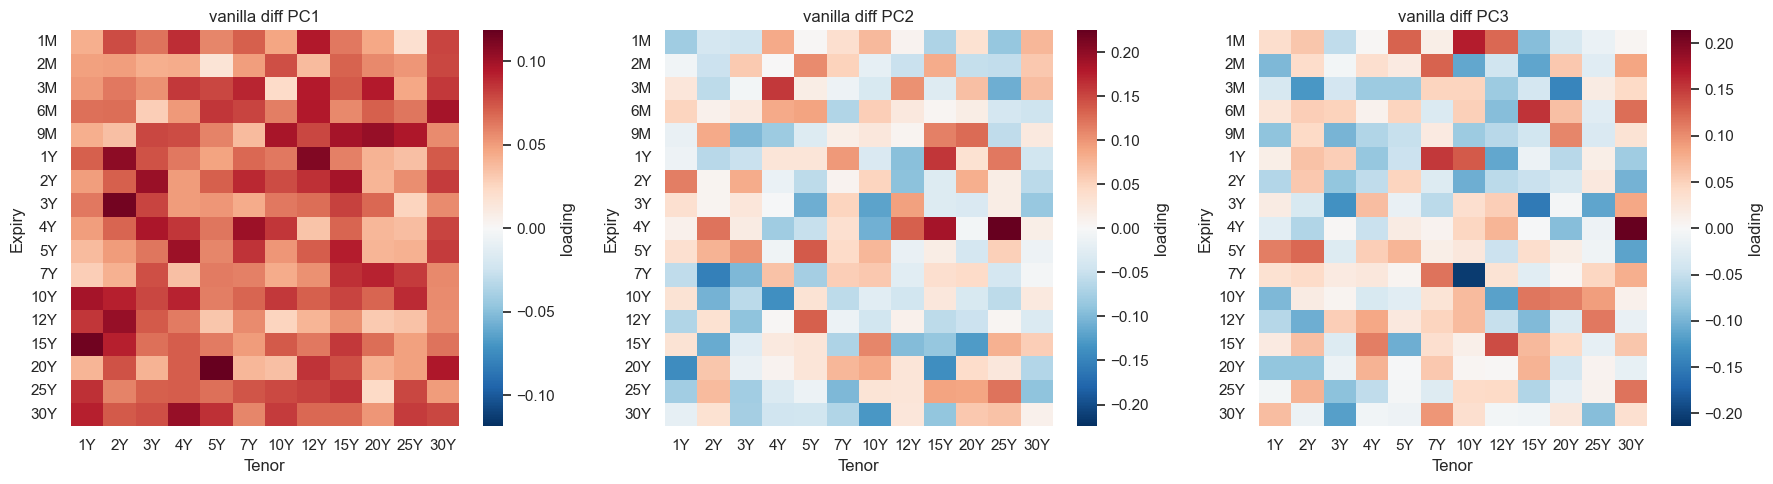

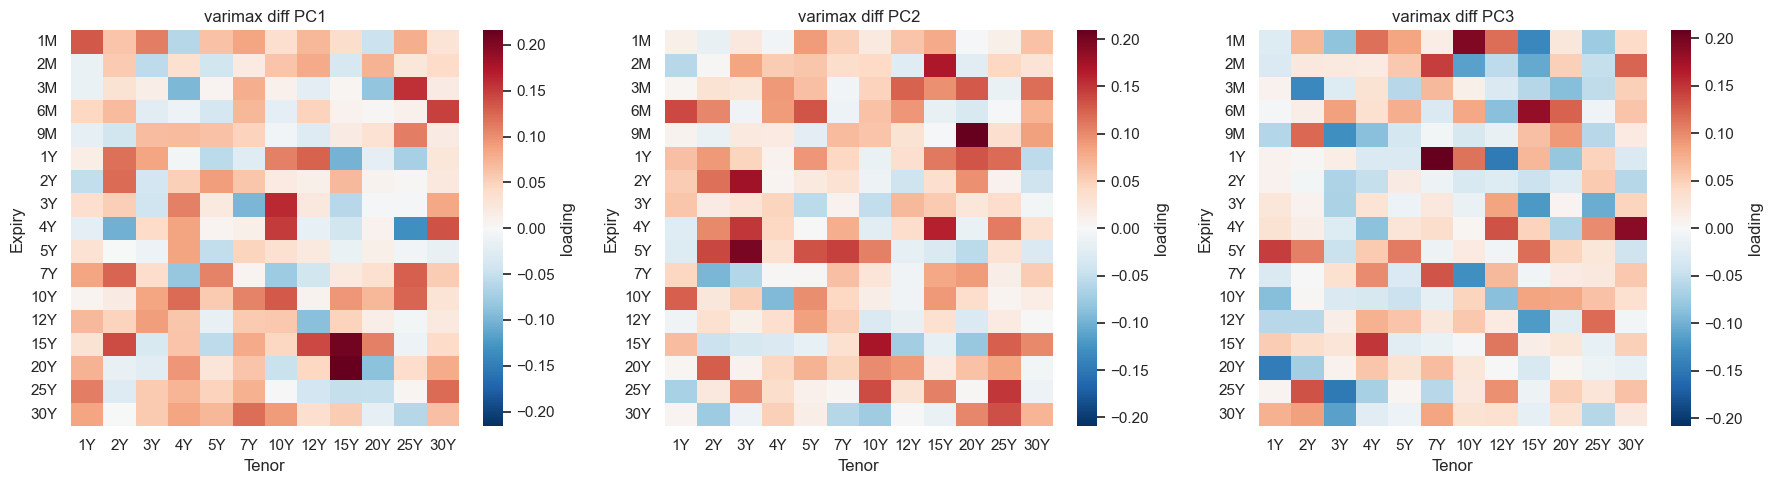

In [2]:
l_rot = varimax(l_van)
s_rot = rotate_scores(s_van, l_van, l_rot)

gini = pd.concat(
    {"vanilla": loading_sparsity(l_van), "varimax": loading_sparsity(l_rot)},
    axis=1,
).round(3)
print(gini)

plot_loadings(l_van, ["PC1", "PC2", "PC3"], "vanilla diff")
plot_loadings(l_rot, ["PC1", "PC2", "PC3"], "varimax diff")

## 2. Block PCA — 3×3 partition

Partition the cube into a 3 (expiry) × 3 (tenor) grid → 9 disjoint
blocks. Fit PCA inside each block independently; stitch the per-block
reconstructions back into the full grid. Each block's PCs live only on
the cells of that block — naturally sparse, naturally hedge-mappable
(short-expiry × short-tenor is one block, long × long is another, …).

Default groups are in `factors.DEFAULT_EXPIRY_BLOCKS` /
`DEFAULT_TENOR_BLOCKS`; pass custom lists to `make_blocks(...)` for
finer / coarser grids.

In [3]:
blocks = make_blocks()
block_results = block_pca(rate, blocks, n_components=2)

print("per-block summary:")
print(block_summary(block_results).to_string(index=False))

per-block summary:
expiry_block tenor_block  n_cells  n_pcs  cum_var_at_1  cum_var_at_2
   short_exp   short_ten       15      2      0.092802      0.182834
   short_exp     mid_ten       20      2      0.081466      0.151749
   short_exp    long_ten       25      2      0.072498      0.132715
     mid_exp   short_ten       15      2      0.115143      0.202804
     mid_exp     mid_ten       20      2      0.087301      0.154291
     mid_exp    long_ten       25      2      0.070810      0.131450
    long_exp   short_ten       21      2      0.092865      0.159180
    long_exp     mid_ten       28      2      0.067953      0.120142
    long_exp    long_ten       35      2      0.059622      0.106520


Stitch every block's PC loadings into a single full-grid heatmap
(each block's PCA is fit independently, so each cell carries the
value from its own block's PC). Thin black lines mark the partition
boundaries. Show PC1 and PC2 side-by-side. Per-block sign is flipped
so the largest-magnitude loading is positive — without that alignment
the nine blocks would show arbitrary red/blue mixes and the visual
story would be lost.

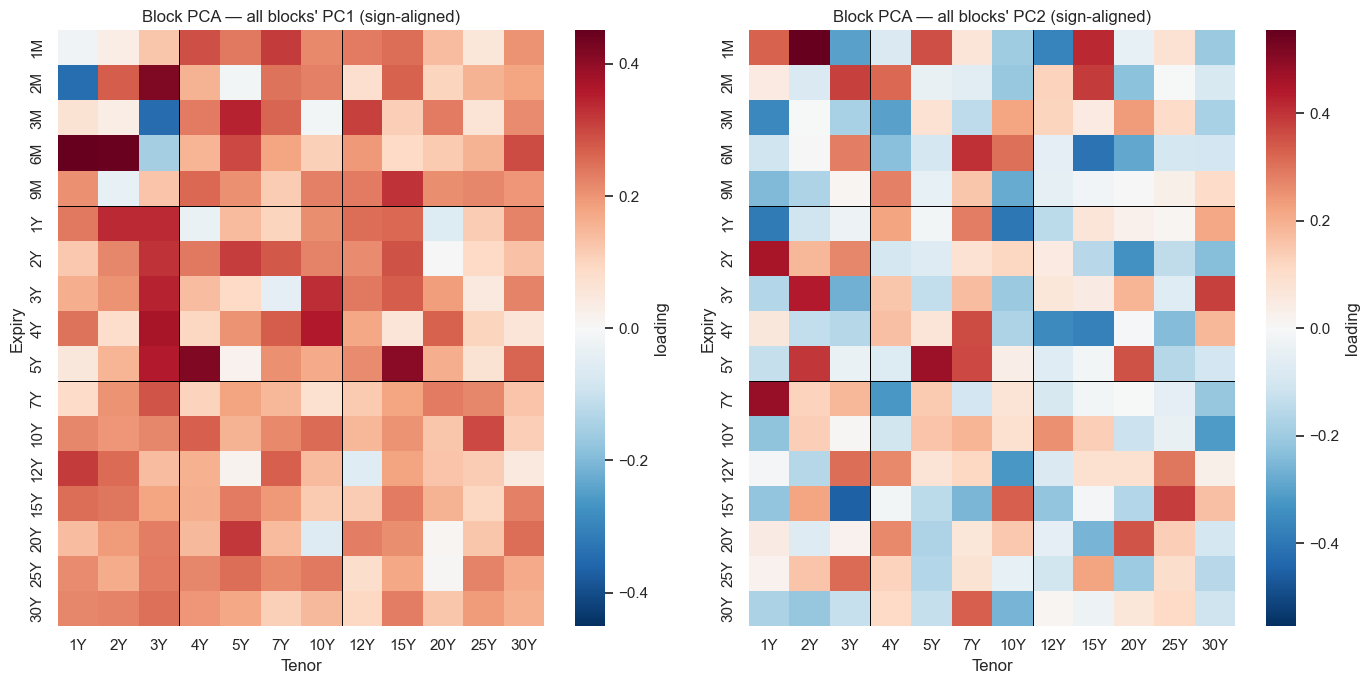

In [4]:
from factors import DEFAULT_EXPIRY_BLOCKS, DEFAULT_TENOR_BLOCKS

expiries = [e for e in EXPIRY_LABELS if e in rate.columns.get_level_values("expiry")]
tenors   = [t for t in TENOR_LABELS if t in rate.columns.get_level_values("tenor")]

def combined_block_grid(pc):
    full = pd.Series(np.nan, index=pd.MultiIndex.from_tuples(
        [(e, t) for e in expiries for t in tenors], names=["expiry", "tenor"],
    ))
    for res in block_results.values():
        if pc not in res["loadings"].index:
            continue
        w = res["loadings"].loc[pc].values
        # sign-align: flip so the largest-magnitude loading is positive.
        if w[np.argmax(np.abs(w))] < 0:
            w = -w
        full.loc[res["loadings"].columns] = w
    return full.unstack("tenor").reindex(index=expiries, columns=tenors)

exp_sizes = [len([e for e in elist if e in expiries]) for _, elist in DEFAULT_EXPIRY_BLOCKS]
ten_sizes = [len([t for t in tlist if t in tenors])   for _, tlist in DEFAULT_TENOR_BLOCKS]
exp_boundaries = np.cumsum(exp_sizes)[:-1]
ten_boundaries = np.cumsum(ten_sizes)[:-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    grid = combined_block_grid(pc)
    vmax = float(grid.abs().max().max())
    sns.heatmap(grid, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                cbar_kws={"label": "loading"})
    for b in exp_boundaries:
        ax.axhline(b, color="black", linewidth=0.7)
    for b in ten_boundaries:
        ax.axvline(b, color="black", linewidth=0.7)
    ax.set_title(f"Block PCA — all blocks' {pc} (sign-aligned)")
    ax.set_xlabel("Tenor"); ax.set_ylabel("Expiry")
plt.tight_layout(); plt.show()

In [5]:
# How well does block PCA reconstruct the full diff surface vs vanilla?
vanilla_5 = run_pca(rate, n_components=18)
for k in (1, 2):
    recon = reconstruct_block(rate, block_results, n_components=k)
    print(f"block (k={k}/block, {9*k} factors total): residual = "
          f"{replication_residual(rate, recon):.3f}")
for k in (5, 9, 18):
    s, l, e = vanilla_5
    recon = reconstruct(s, l, rate, k)
    print(f"vanilla (K={k}): residual = {replication_residual(rate, recon):.3f}")

block (k=1/block, 9 factors total): residual = 0.921
block (k=2/block, 18 factors total): residual = 0.859
vanilla (K=5): residual = 0.906
vanilla (K=9): residual = 0.854
vanilla (K=18): residual = 0.748


## 3. Regression on bucket / block factors

`factors.regress(targets, factors)` is a one-line OLS for any factor
design vs any target panel — `betas`, `fitted`, `residuals`, and
per-target `r2` come back in a dict. Below are three useful starting
tests. Reach for `regress` whenever you have a pattern (block PCs,
varimax PCs, custom buckets, anything else) and want to see how much
of the cube it explains.

In [6]:
# (a) within-surface: rate cells ~ rate block PCs.
rate_block_pc1 = stack_block_scores(block_results, top_k=1)  # 9 factors
rate_block_pc2 = stack_block_scores(block_results, top_k=2)  # 18 factors

res_pc1 = regress(rate, rate_block_pc1)
res_pc2 = regress(rate, rate_block_pc2)

# (b) cross-surface: vol cells ~ rate block PCs.
vol_blocks = block_pca(vol, blocks, n_components=2)
res_cross = regress(vol, rate_block_pc1)

print("R² distribution across the 204 cube cells:")
summary = pd.concat(
    {
        "rate ~ rate_block_PC1 (9f)":  res_pc1["r2"].describe(),
        "rate ~ rate_block_PC1+2 (18f)": res_pc2["r2"].describe(),
        "vol  ~ rate_block_PC1 (9f)":  res_cross["r2"].describe(),
    },
    axis=1,
).round(3)
print(summary)

R² distribution across the 204 cube cells:
       rate ~ rate_block_PC1 (9f)  rate ~ rate_block_PC1+2 (18f)  \
count                     204.000                        204.000   
mean                        0.104                          0.187   
std                         0.063                          0.086   
min                         0.009                          0.037   
25%                         0.057                          0.122   
50%                         0.093                          0.176   
75%                         0.132                          0.232   
max                         0.317                          0.480   

       vol  ~ rate_block_PC1 (9f)  
count                     204.000  
mean                        0.108  
std                         0.023  
min                         0.051  
25%                         0.091  
50%                         0.105  
75%                         0.125  
max                         0.177  


Per-cell R² heatmaps. The within-surface heatmap should light up
block-by-block (each cell is best explained by *its own* block's PCs).
The cross-surface heatmap is uniformly weaker — small but non-zero
patches mark where rate moves carry information about vol moves.

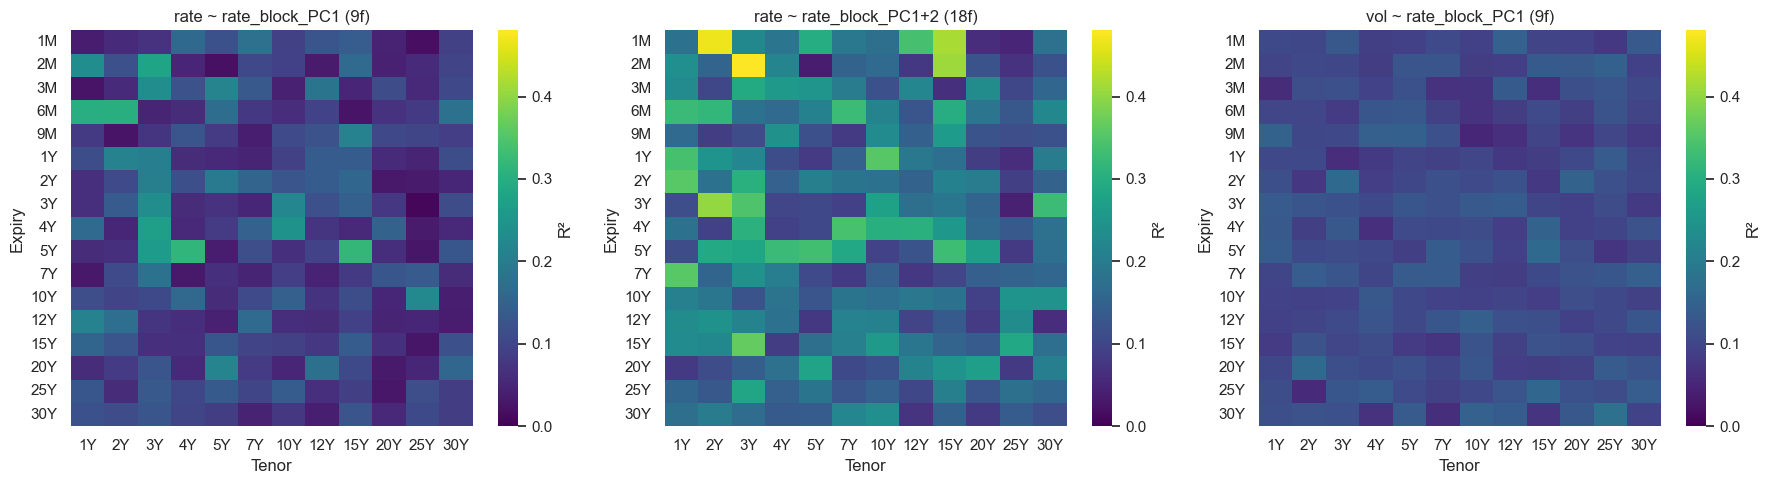

In [7]:
panels = [
    ("rate ~ rate_block_PC1 (9f)",   res_pc1["r2"]),
    ("rate ~ rate_block_PC1+2 (18f)", res_pc2["r2"]),
    ("vol ~ rate_block_PC1 (9f)",    res_cross["r2"]),
]
vmax = max(float(s.max()) for _, s in panels)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, r2) in zip(axes, panels):
    sns.heatmap(r2_grid(r2), ax=ax, cmap="viridis", vmin=0, vmax=vmax,
                cbar_kws={"label": "R²"})
    ax.set_title(title)
    ax.set_xlabel("Tenor"); ax.set_ylabel("Expiry")
plt.tight_layout(); plt.show()

In [8]:
# A typical use of `betas`: pick one cell and inspect which block
# factors carry the most weight. In a DGP where blocks share common
# drivers (as in mock_data.py — every cell sees the same dLevel /
# dSlope), nearby-block PCs will also rank highly; the cell's *own*
# block usually appears in the top few but isn't guaranteed to be #1.
cell = ("5Y", "10Y")  # mid_exp × mid_ten by the default partition
top = res_pc1["betas"][cell].abs().sort_values(ascending=False).head(5)
print(f"top |beta| explaining {cell}:")
print(top.round(3))

top |beta| explaining ('5Y', '10Y'):
mid_exp|mid_ten|PC1        0.044
mid_exp|long_ten|PC1       0.021
mid_exp|short_ten|PC1      0.013
long_exp|mid_ten|PC1       0.011
short_exp|short_ten|PC1    0.010
Name: (5Y, 10Y), dtype: float64


## 4. Joint rate-vol structure (CCA on block factors)

Stack the per-block PC1 series into a flat (date × 9) score panel for
each surface, then CCA the two panels. This asks 'is there a linear
combination of vol-block factors that matches a linear combination of
rate-block factors?' — answering the README's 'shared latent drivers'
question at the block-localised level rather than at the global PC
level.

`lagged_corr` is a sanity check on the highest-correlation pair: is
the relationship contemporaneous, or does one side lead?

canonical correlations (rate-blocks vs vol-blocks):
CC1    0.883
CC2    0.257
CC3    0.202
CC4    0.174
CC5    0.120
Name: canonical_corr, dtype: float64

for reference — global PC vs PC canonical corrs:
CC1    0.900
CC2    0.142
CC3    0.096
Name: canonical_corr, dtype: float64


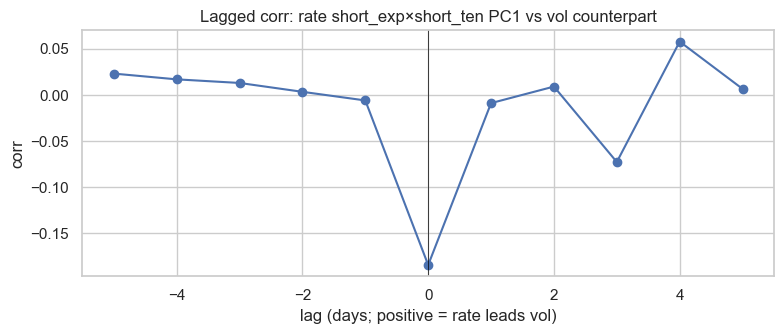

In [9]:
vol_block_scores = stack_block_scores(vol_blocks, top_k=1)

_, _, canon = cross_surface_cca(rate_block_pc1, vol_block_scores, n_components=5)
print("canonical correlations (rate-blocks vs vol-blocks):")
print(canon.round(3))

# also keep the global PC-vs-PC view for orientation
s_vol, l_vol, e_vol = run_pca(vol, n_components=5)
_, _, canon_global = cross_surface_cca(s_van, s_vol, n_components=3)
print("\nfor reference — global PC vs PC canonical corrs:")
print(canon_global.round(3))

lc = lagged_corr(rate_block_pc1.iloc[:, 0], vol_block_scores.iloc[:, 0], range(-5, 6))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(lc.index, lc.values, marker="o")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("lag (days; positive = rate leads vol)")
ax.set_ylabel("corr")
ax.set_title("Lagged corr: rate short_exp×short_ten PC1 vs vol counterpart")
plt.tight_layout(); plt.show()

## 5. Comparison metrics

Two tables. The first compares the single-panel methods (vanilla,
varimax) using the four shared metrics. The second is a per-block
summary for block PCA — the cumulative-variance metric isn't directly
comparable across methods because block PCAs are fit on different
panels, but per-block share + the aggregate `replication_residual`
from Section 2 covers the same ground.

* `var_at_K`           — cumulative explained variance at K PCs.
* `resid_at_K`         — residual variance fraction after K-PC
  reconstruction of the diff surface (lower = better hedge replication).
* `loading_gini_mean`  — average Gini across PC loadings (1 = sparse).
* `stability_mean`     — average rolling-window cosine similarity of
  loadings vs full-sample loadings (1 = perfectly stable).

In [10]:
repl_van = {k: replication_residual(rate, reconstruct(s_van, l_van, rate, k))
            for k in (1, 3, 5)}
repl_rot = {k: replication_residual(rate, reconstruct(s_rot, l_rot, rate, k))
            for k in (1, 3, 5)}

single_panel = pd.concat([
    metrics_table("vanilla", rate, s_van, l_van, e_van, replication=repl_van),
    metrics_table("varimax", rate, s_rot, l_rot, e_van, replication=repl_rot),
], ignore_index=True)
print("Single-panel methods:")
print(single_panel.round(3).to_string(index=False))

print("\nBlock PCA — per-block summary:")
print(block_summary(block_results).round(3).to_string(index=False))

print("\nBlock PCA — aggregate replication residual:")
for k in (1, 2):
    recon = reconstruct_block(rate, block_results, n_components=k)
    print(f"  {k} PCs/block ({9*k} factors total): {replication_residual(rate, recon):.3f}")

Single-panel methods:
 method  loading_gini_mean  stability_mean  var_at_1  resid_at_1  var_at_3  resid_at_3  var_at_5  resid_at_5
vanilla              0.357           0.517     0.037       0.963     0.066       0.934     0.094       0.906
varimax              0.420           0.517     0.037       0.980     0.066       0.945     0.094       0.906

Block PCA — per-block summary:
expiry_block tenor_block  n_cells  n_pcs  cum_var_at_1  cum_var_at_2
   short_exp   short_ten       15      2         0.093         0.183
   short_exp     mid_ten       20      2         0.081         0.152
   short_exp    long_ten       25      2         0.072         0.133
     mid_exp   short_ten       15      2         0.115         0.203
     mid_exp     mid_ten       20      2         0.087         0.154
     mid_exp    long_ten       25      2         0.071         0.131
    long_exp   short_ten       21      2         0.093         0.159
    long_exp     mid_ten       28      2         0.068         0.12

## Notes for production hand-off

* Swap `data/mock/*.pkl` for real-data pkls of the same shape — the
  notebook needs no other change. Diff() is applied at load time.
* The 3×3 partition in `DEFAULT_EXPIRY_BLOCKS` / `DEFAULT_TENOR_BLOCKS`
  is the only hand-tuned input. Adjust to taste (finer grid → smaller
  per-block residual but more total factors).
* `regress(targets, factors)` is the workhorse for any other pattern
  you want to test — varimax PCs, hand-built spreads, lagged factors,
  whatever. Same interface, just a different factor panel in.